## Importation des packages et des données 

In [50]:
import pandas as pd
from fanalysis.ca import CA
import numpy as np
import matplotlib.pyplot as plt

In [51]:

df = pd.read_excel('Statitic_election2025.xlsx')
df

,Region,Centre,Est,Extreme nord,Littoral,Nord,Nord-Ouest,Ouest
0,Belo bouba,4331,3833,28778,6757,33876,5325,7392
1,Biya Paul,722153,192543,329476,137679,154926,255188,201731
2,Issa chiroma,200654,51660,30300,423557,173837,50392,24315
3,Hiram Samuel,4039,665,2617,5206,2550,367,1239
4,Cabrel,62118,6214,7782,59447,4451,593,4641
5,oshi,4436,784,3517,10904,2237,60292,5617
6,dam njoya,2829,1003,9487,4047,6145,500,49296


In [52]:
df.columns = df.columns.str.strip().str.replace('\ufeff', '', regex=False)


# Liste des colonnes à partir de 'Centre' jusqu'à la fin
Region_names = list(df.columns)[1:]   # car index 0='Candidat', index 1='Region'

# Extraction de la colonne 'Region'
Candidate_names = df['Region']

In [53]:
X=df[Region_names].values

In [54]:
row_sum=np.sum(X, axis=1)
row_profile=X/row_sum[:, np.newaxis]
print('profil ligne:')
print(pd.DataFrame(row_profile, index=Candidate_names, columns=Region_names))

profil ligne:
                Centre       Est  Extreme nord  Littoral      Nord  \
Region                                                               
Belo bouba    0.047967  0.042451      0.318721  0.074835  0.375183   
Biya Paul     0.362218  0.096576      0.165259  0.069057  0.077708   
Issa chiroma  0.210172  0.054110      0.031737  0.443648  0.182083   
Hiram Samuel  0.242103  0.039861      0.156866  0.312054  0.152850   
Cabrel        0.427674  0.042783      0.053578  0.409285  0.030645   
oshi          0.050531  0.008931      0.040063  0.124210  0.025482   
dam njoya     0.038591  0.013682      0.129415  0.055206  0.083826   

              Nord-Ouest     Ouest  
Region                              
Belo bouba      0.058975  0.081868  
Biya Paul       0.127997  0.101184  
Issa chiroma    0.052782  0.025468  
Hiram Samuel    0.021998  0.074267  
Cabrel          0.004083  0.031953  
oshi            0.686799  0.063984  
dam njoya       0.006821  0.672460  


In [55]:
# Calcul du profil colonne
col_sum = np.sum(X, axis=0)
col_profile = X / col_sum[np.newaxis, :]

# Affichage
print("Profil colonne:")
print(pd.DataFrame(col_profile, index=Candidate_names, columns=Region_names))

Profil colonne:
                Centre       Est  Extreme nord  Littoral      Nord  \
Region                                                               
Belo bouba    0.004329  0.014932      0.069857  0.010434  0.089614   
Biya Paul     0.721749  0.750064      0.799783  0.212600  0.409833   
Issa chiroma  0.200542  0.201245      0.073551  0.654044  0.459859   
Hiram Samuel  0.004037  0.002591      0.006353  0.008039  0.006746   
Cabrel        0.062083  0.024207      0.018890  0.091796  0.011774   
oshi          0.004434  0.003054      0.008537  0.016838  0.005918   
dam njoya     0.002827  0.003907      0.023029  0.006249  0.016256   

              Nord-Ouest     Ouest  
Region                              
Belo bouba      0.014289  0.025123  
Biya Paul       0.684780  0.685621  
Issa chiroma    0.135224  0.082639  
Hiram Samuel    0.000985  0.004211  
Cabrel          0.001591  0.015773  
oshi            0.161790  0.019090  
dam njoya       0.001342  0.167542  


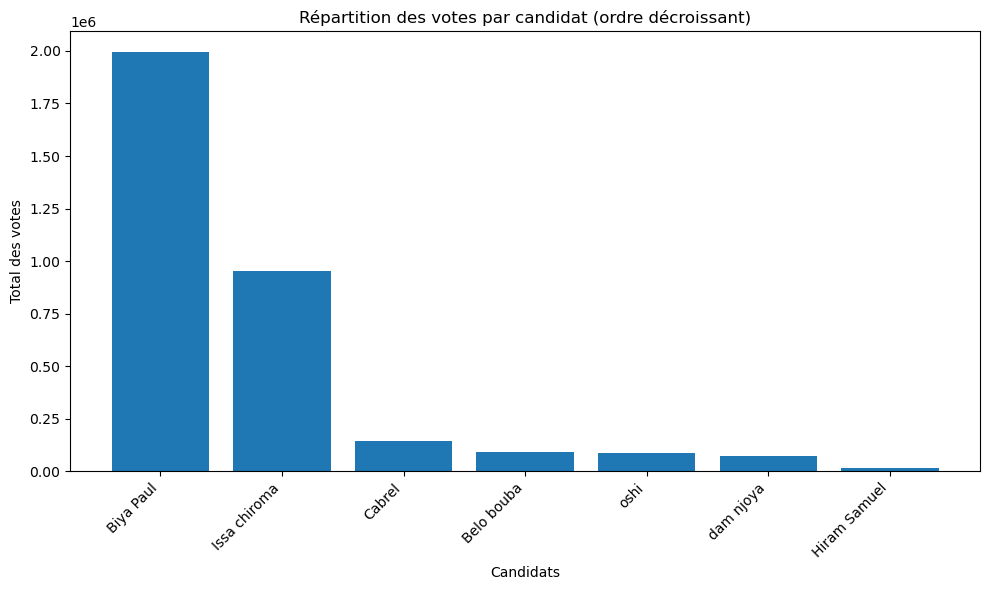

In [56]:

# Liste des colonnes contenant les votes par région
col_names = list(df.columns)[1:]  # on ignore la première colonne ('Region' qui contient les candidats)

# Calcul du total des votes par candidat
df['Total'] = df[col_names].sum(axis=1)

# Tri décroissant des candidats selon le total
df_sorted = df.sort_values(by='Total', ascending=False)

# Création du diagramme en barres
plt.figure(figsize=(10, 6))
plt.bar(df_sorted['Region'], df_sorted['Total'])

# Ajout des labels et du titre
plt.xlabel('Candidats')
plt.ylabel('Total des votes')
plt.title('Répartition des votes par candidat (ordre décroissant)')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()


In [57]:
df=df.set_index("Region")
# On crée une instale de la classe CA en passant les étiquettes de lignes et les colonnes

my_ca=CA(row_labels=df.index.values,col_labels=df.columns.values,stats=True)
# Estime l'AFC
my_ca.fit(df.values)
# Identification des valeurs propres
my_ca.eig_

C:\Users\lenovo\anaconda3\Lib\site-packages\fanalysis\base.py:306: RuntimeWarning: invalid value encountered in divide
  col_cos2 = ((self.col_coord_ ** 2)


array([[1.26052417e-01, 5.12424285e-02, 3.84197874e-02, 2.03284757e-02,
        1.04978918e-03, 9.01975053e-06],
       [5.31638118e+01, 2.16119840e+01, 1.62039126e+01, 8.57372891e+00,
        4.42758621e-01, 3.80416600e-03],
       [5.31638118e+01, 7.47757957e+01, 9.09797083e+01, 9.95534372e+01,
        9.99961958e+01, 1.00000000e+02]])

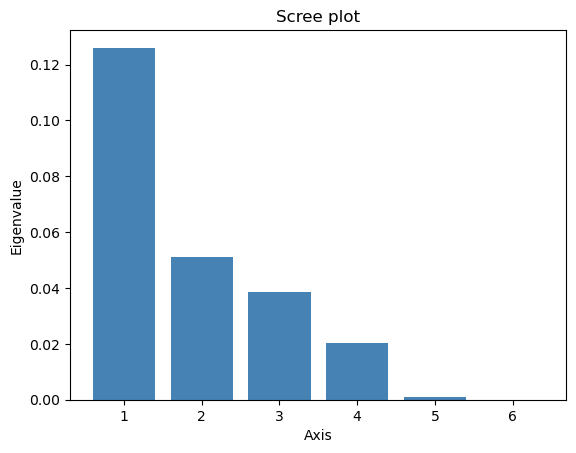

In [58]:
# Graphique des valeurs propres
my_ca.plot_eigenvalues()

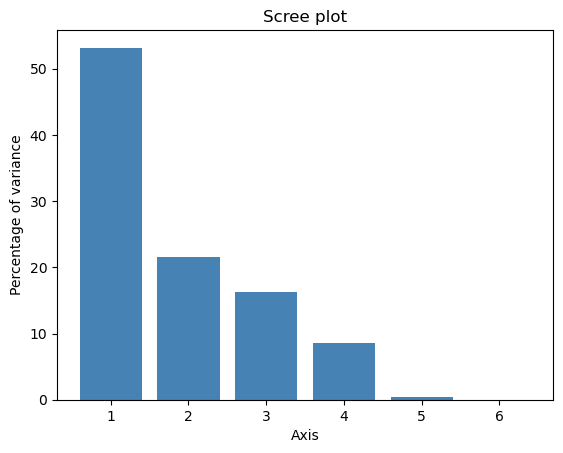

In [59]:
my_ca.plot_eigenvalues(type="percentage")


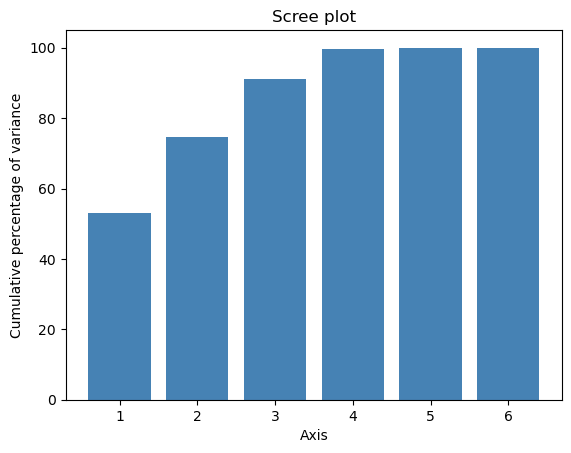

In [60]:
my_ca.plot_eigenvalues(type="cumulative")


Premier axe factoriel


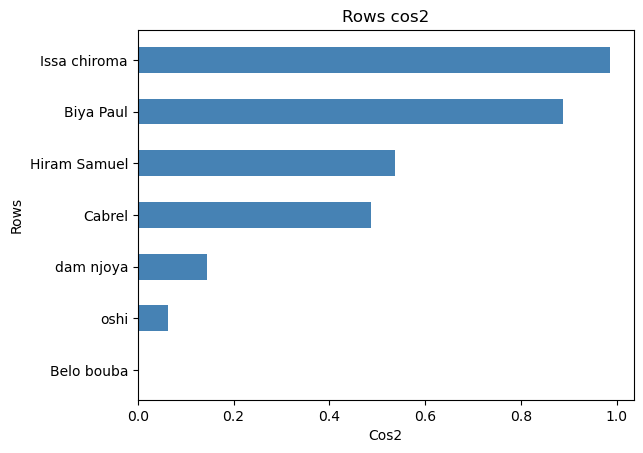

Second axe factoriel


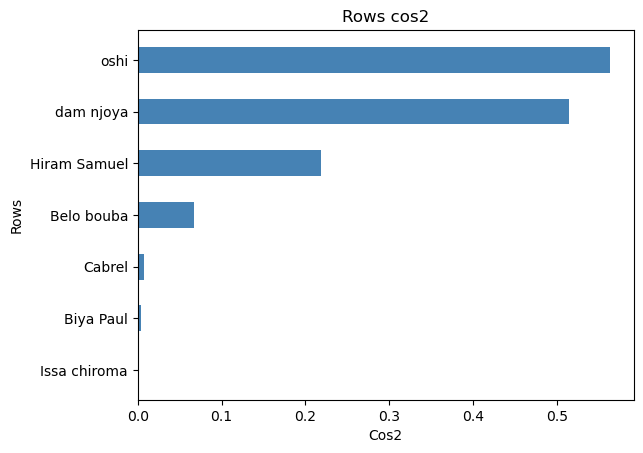

In [61]:
# Classement des points colonnes en fonction de leur contribution au 1er axe
print("Premier axe factoriel")
my_ca.plot_row_cos2(num_axis=1)
print("Second axe factoriel")
my_ca.plot_row_cos2(num_axis=2)


Premier axe factoriel


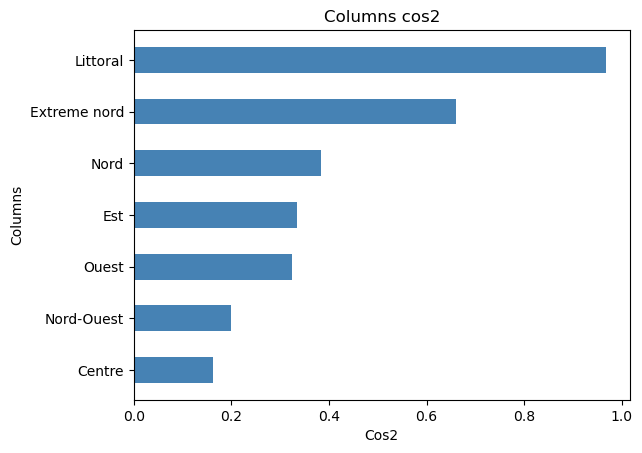

Second axe factoriel


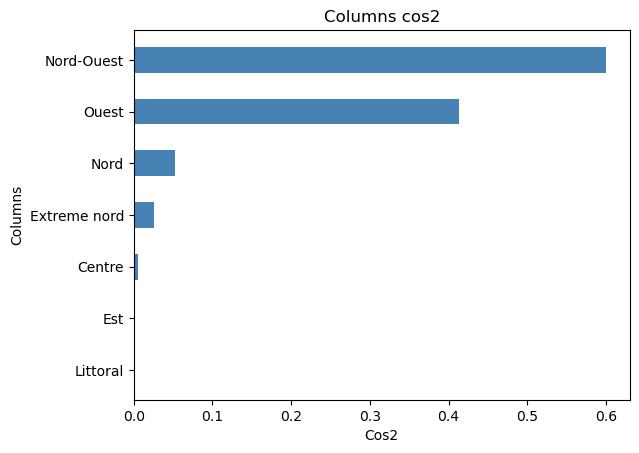

In [62]:
#### Profil colonne 

print("Premier axe factoriel")
my_ca.plot_col_cos2(num_axis=1)
print("Second axe factoriel")
my_ca.plot_col_cos2(num_axis=2)

In [63]:
info_dep=my_ca.row_topandas()
info_dep

,row_coord_dim1,row_coord_dim2,row_coord_dim3,row_coord_dim4,row_coord_dim5,row_coord_dim6,row_contrib_dim1,row_contrib_dim2,row_contrib_dim3,row_contrib_dim4,row_contrib_dim5,row_contrib_dim6,row_cos2_dim1,row_cos2_dim2,row_cos2_dim3,row_cos2_dim4,row_cos2_dim5,row_cos2_dim6
Belo bouba,0.045404,0.204270,-0.049470,0.756206,0.080368,0.003084,0.043925,2.187083,0.171084,75.554892,16.525215,2.831919,0.003301,0.066810,0.003918,0.915614,0.010342,1.522721e-05
Biya Paul,0.239419,-0.015745,0.082511,-0.010135,-0.006793,-0.000059,26.968898,0.286928,10.509175,0.299651,2.606677,0.022945,0.888342,0.003842,0.105509,0.001592,0.000715,5.408192e-08
Issa chiroma,-0.517904,0.012496,-0.056665,0.011526,-0.017750,-0.000018,60.430875,0.086537,2.373496,0.185603,8.522919,0.001021,0.985976,0.000574,0.011803,0.000488,0.001158,1.192187e-09
Hiram Samuel,-0.231412,0.147571,0.025150,0.082818,0.122912,-0.040839,0.210830,0.210903,0.008170,0.167441,7.141693,91.764700,0.537691,0.218656,0.006351,0.068868,0.151688,1.674631e-02
Cabrel,-0.366599,0.046156,0.174877,-0.305931,0.122987,0.003329,4.606520,0.179625,3.439142,19.892195,62.252847,5.309094,0.487225,0.007723,0.110869,0.339307,0.054836,4.018094e-05
oshi,0.327001,-0.980345,-0.797146,-0.024952,0.034218,0.000212,2.215209,48.977453,43.190506,0.079979,2.912491,0.012995,0.062706,0.563602,0.372640,0.000365,0.000687,2.632144e-08
dam njoya,0.565068,1.062838,-0.842721,-0.188715,0.004286,0.000487,5.523743,48.071471,40.308427,3.820239,0.038158,0.057326,0.145485,0.514697,0.323583,0.016227,0.000008,1.080394e-07


In [64]:
info_candidat=my_ca.col_topandas()
info_candidat

,col_coord_dim1,col_coord_dim2,col_coord_dim3,col_coord_dim4,col_coord_dim5,col_coord_dim6,col_contrib_dim1,col_contrib_dim2,col_contrib_dim3,col_contrib_dim4,col_contrib_dim5,col_contrib_dim6,col_cos2_dim1,col_cos2_dim2,col_cos2_dim3,col_cos2_dim4,col_cos2_dim5,col_cos2_dim6
Centre,0.136575,-0.025861,0.270477,-0.147519,0.005589,0.003744,2.202118,0.194234,28.337195,15.930978,0.442854,23.129339,0.163210,0.005852,0.640127,0.190415,0.000273,1.226626e-04
Est,0.196499,-0.015846,0.246506,-0.013995,-0.125004,-0.008172,1.169522,0.018708,6.038628,0.036784,56.830727,28.269612,0.334254,0.002174,0.526029,0.001695,0.135270,5.781372e-04
Extreme nord,0.461842,0.090613,0.181716,0.250785,0.073175,-0.005550,10.368027,0.981773,5.266145,18.956447,31.252119,20.921157,0.660759,0.025435,0.102292,0.194831,0.016587,9.540604e-05
Littoral,-0.883942,0.011111,-0.114632,-0.110415,0.020560,-0.002747,59.704711,0.023204,3.294356,5.776454,3.878324,8.059125,0.967933,0.000153,0.016278,0.015103,0.000524,9.349061e-06
Nord,-0.368211,0.135237,-0.065623,0.439441,-0.036876,0.005576,6.047391,2.006727,0.630209,53.409831,7.283018,19.377946,0.384433,0.051858,0.012211,0.547554,0.003856,8.814616e-05
Nord-Ouest,0.415216,-0.720678,-0.416636,0.005111,-0.001382,0.000395,7.580769,56.178420,25.042411,0.007123,0.010080,0.095909,0.199220,0.600162,0.200586,0.000030,0.000002,1.803523e-07
Ouest,0.610217,0.689467,-0.524967,-0.165303,-0.008524,0.000550,12.927462,40.596933,31.391055,5.882382,0.302877,0.146912,0.323593,0.413103,0.239495,0.023746,0.000063,2.631397e-07
Total,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN


In [71]:
info_candidat.to_excel('Coordonnees regions.xlsx', index=True)

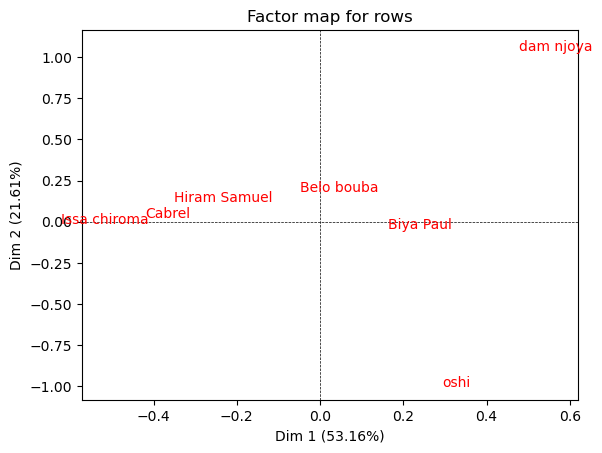

In [70]:
# Graphique des départements (en ligne)
my_ca.mapping_row(num_x_axis=1,num_y_axis=2)



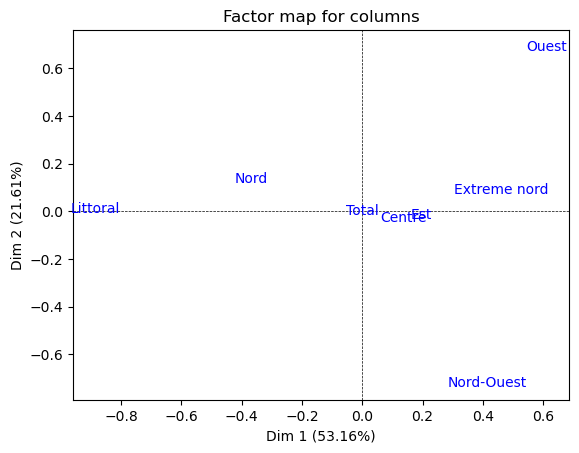

In [66]:
# Graphique des candidats (en colonne)
my_ca.mapping_col(num_x_axis=1,num_y_axis=2)

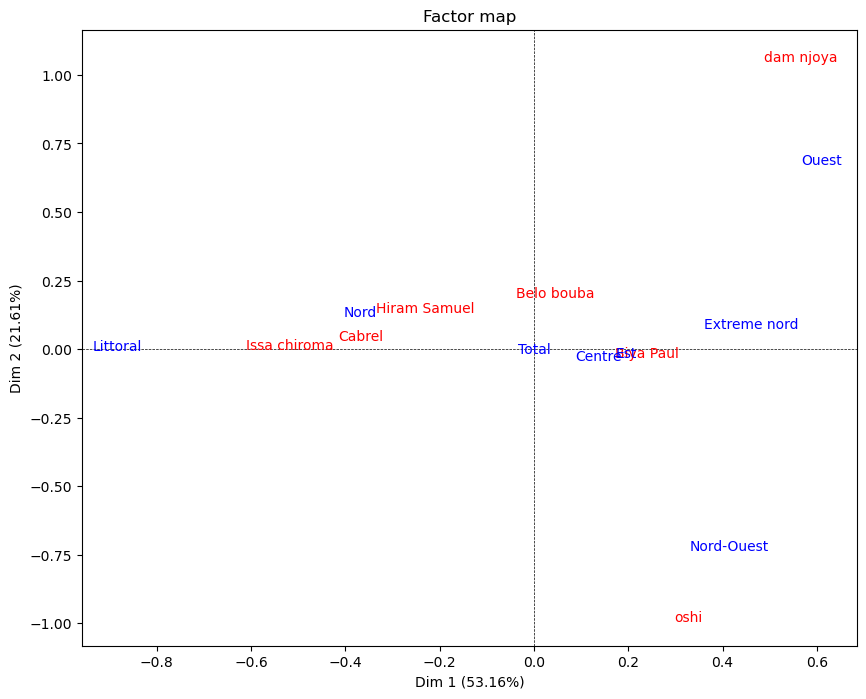

In [67]:
# Graphique profil ligne profil colonne

my_ca.mapping(1, 2, figsize=(10, 8))